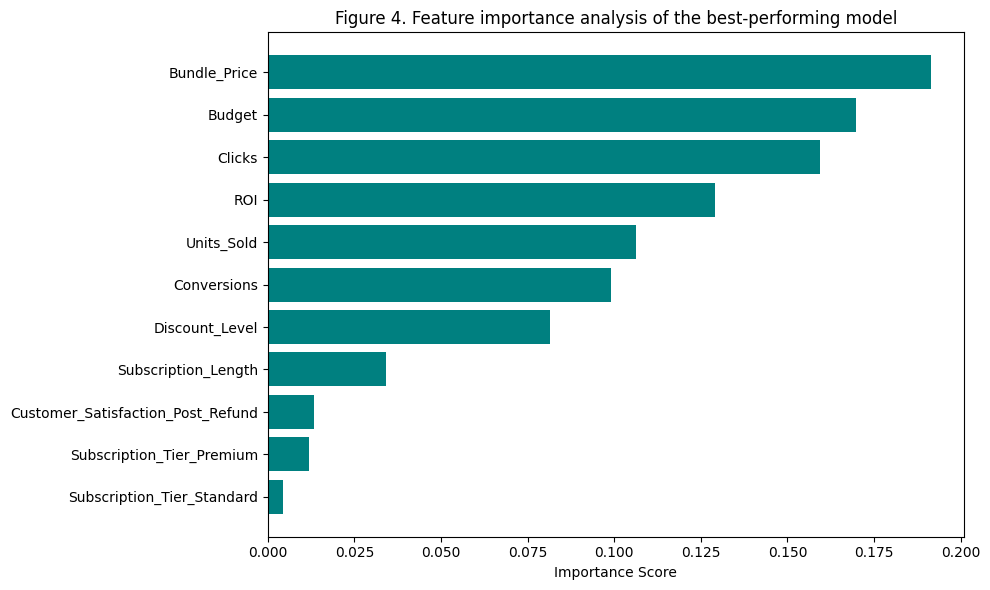

RQ4 Complete! Check Output folder for Table IV and Figure 4.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# 1. Load Data
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')

# 2. Cleaning & Prep
cols_to_drop = ['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords']
df_clean = df.drop(columns=cols_to_drop)
df_clean = pd.get_dummies(df_clean, columns=['Subscription_Tier'], drop_first=True)

X = df_clean.drop(columns=['Revenue_Generated'])
y = df_clean['Revenue_Generated']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# 4. Extract Feature Importance
importances = model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# 5. Save Table IV
feat_imp_df.to_csv('RQ4_Feature_Importance.csv', index=False)

# 6. Save Figure 4 (Horizontal Bar Chart)
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Figure 4. Feature importance analysis of the best-performing model')
plt.gca().invert_yaxis() # Highest importance on top
plt.tight_layout()
plt.savefig('RQ4_Feature_Importance_Plot.pdf')
plt.show()

print("RQ4 Complete! Check Output folder for Table IV and Figure 4.")